<a href="https://colab.research.google.com/github/Raulfb04/Simulaci-n-1/blob/main/Distribuci%C3%B3n_de_Poisson.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación de una distribución discreta de probabilidad

En esta práctica se simula una variable aleatoria discreta usando números aleatorios uniformes en el intervalo $(0,1)$.

La idea principal es dividir el intervalo $(0,1)$ en subintervalos cuya longitud corresponde a la probabilidad de cada valor posible de la variable aleatoria.

Esto permite transformar números aleatorios uniformes en valores de una distribución de probabilidad específica.

Este procedimiento es útil porque en simulación muchas veces necesitamos generar datos artificiales que sigan cierto comportamiento probabilístico. La base teórica viene de la probabilidad discreta, donde el valor esperado se calcula como:

$E[X]=\sum_i x_iP(X=x_i)$

y de la idea de generar muestras aleatorias para aproximar resultados mediante simulación.

In [5]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

## Definición de la distribución

La variable aleatoria $X$ puede tomar los valores:

$X = 1, 2, 3, 4$

con probabilidades:

$P(X=1)=0.20$

$P(X=2)=0.15$

$P(X=3)=0.25$

$P(X=4)=0.40$

La suma de las probabilidades es:

$0.20+0.15+0.25+0.40=1$

Por lo tanto, sí corresponde a una distribución de probabilidad discreta.

In [6]:
def generar_muestra(n):
    L = []

    for i in range(n):
        R = r.random()

        if 0 <= R <= 0.20:
            x = 1
        elif 0.20 < R <= 0.35:
            x = 2
        elif 0.35 < R <= 0.60:
            x = 3
        else:
            x = 4

        L.append(x)

    return L

## Generación de la muestra

Ahora generamos una muestra de tamaño $n=1000$.

Cada número aleatorio uniforme se transforma en un valor de $X$ dependiendo del intervalo en el que cae.

In [7]:
M = generar_muestra(1000)

print(M[:20])

[4, 2, 4, 1, 3, 4, 3, 4, 3, 4, 2, 3, 3, 2, 4, 1, 4, 3, 4, 1]


## Histograma de la simulación

El histograma permite visualizar qué tan frecuentemente aparece cada valor de la variable aleatoria.

Como se usa `density=True`, las alturas representan frecuencias relativas aproximadas.

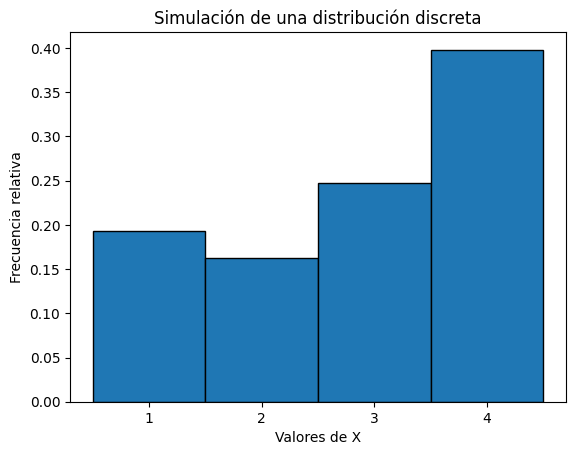

In [8]:
plt.hist(M, bins=[0.5, 1.5, 2.5, 3.5, 4.5], density=True, edgecolor="black")
plt.xticks([1, 2, 3, 4])
plt.xlabel("Valores de X")
plt.ylabel("Frecuencia relativa")
plt.title("Simulación de una distribución discreta")
plt.show()

## Comparación con las probabilidades teóricas

Calculamos las frecuencias relativas obtenidas en la simulación y las comparamos con las probabilidades teóricas.

In [9]:
valores, conteos = np.unique(M, return_counts=True)
frecuencias = conteos / len(M)

for valor, frecuencia in zip(valores, frecuencias):
    print(f"P(X={valor}) aproximada = {frecuencia:.4f}")

P(X=1) aproximada = 0.1930
P(X=2) aproximada = 0.1620
P(X=3) aproximada = 0.2470
P(X=4) aproximada = 0.3980


## Interpretación

Los resultados simulados no tienen que ser exactamente iguales a las probabilidades teóricas, porque dependen del azar.

Sin embargo, cuando el tamaño de la muestra es grande, las frecuencias relativas tienden a acercarse a las probabilidades reales.

Esto se relaciona con la ley de los grandes números, la cual establece que el promedio de muchas observaciones aleatorias tiende al valor esperado de la variable.